

> Add blockquote# Project 1: Sentiment Analysis on Twitter Data
**Intern Name:** MEDAM GIRISWARAREDDY  
**Internship ID:**  E19E86-0116588288923  
**Company:** Codec Technologies  
---



### **Project Overview: Handwritten Digit Recognizer**

This project aims to build a neural network model that can accurately recognize handwritten digits (0-9) from images. We will use the popular MNIST dataset, which contains a large collection of handwritten digits.

**Key Steps:**
1.  **Load the Dataset**: Import the MNIST dataset.
2.  **Preprocess Data**: Normalize pixel values and reshape images.
3.  **Build Model**: Create a Convolutional Neural Network (CNN) architecture.
4.  **Compile Model**: Configure the model for training.
5.  **Train Model**: Train the model using the preprocessed data.
6.  **Evaluate Model**: Assess the model's performance on unseen data.
7.  **Make Predictions**: Use the trained model to predict digits.

### **Step 1: Import Libraries and Load the MNIST Dataset**

We'll start by importing necessary libraries like TensorFlow and NumPy, and then load the MNIST dataset, which is conveniently available in Keras.

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


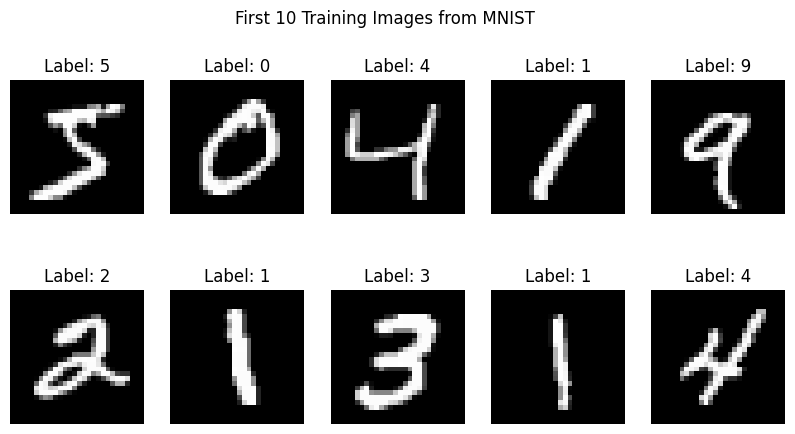

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Training data shape: {x_train.shape}") # (60000, 28, 28)
print(f"Training labels shape: {y_train.shape}") # (60000,)
print(f"Test data shape: {x_test.shape}") # (10000, 28, 28)
print(f"Test labels shape: {y_test.shape}") # (10000,)

# Display the first few training images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("First 10 Training Images from MNIST")
plt.show()

### **Step 2: Data Preprocessing**

For deep learning models, it's crucial to preprocess the data. This involves:
1.  **Normalization**: Scaling pixel values from [0, 255] to [0, 1] to help the model converge faster.
2.  **Reshaping**: Adding a channel dimension to the images (e.g., from (28, 28) to (28, 28, 1)) because CNNs expect a channel dimension (1 for grayscale, 3 for RGB).
3.  **One-Hot Encoding**: Converting integer labels (0-9) into a binary vector format, which is required for categorical cross-entropy loss.

In [17]:
# Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images to add a channel dimension (for CNNs)
# MNIST images are 28x28 grayscale, so we add a channel of 1
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"Preprocessed training data shape: {x_train.shape}")
print(f"Preprocessed training labels shape: {y_train.shape}")

Preprocessed training data shape: (60000, 28, 28, 1)
Preprocessed training labels shape: (60000, 10)


### **Step 3: Build the Convolutional Neural Network (CNN) Model**

CNNs are particularly effective for image recognition tasks. A typical CNN architecture for digit recognition includes:
*   **Convolutional Layers (`Conv2D`)**: Extract features from images.
*   **Activation Function (`ReLU`)**: Introduce non-linearity.
*   **Pooling Layers (`MaxPooling2D`)**: Reduce dimensionality and computational load, helping to make the model more robust to small shifts in input.
*   **Flatten Layer**: Convert the 2D feature maps into a 1D vector.
*   **Dense (Fully Connected) Layers**: Perform classification based on the extracted features.
*   **Output Layer (`Softmax`)**: Output probabilities for each digit class (0-9).

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(), # Add BatchNormalization
    MaxPooling2D((2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(), # Add BatchNormalization
    MaxPooling2D((2, 2)),

    # Flatten the 2D feature maps to 1D vector
    Flatten(),

    # Dense layers
    Dense(128, activation='relu'),
    Dropout(0.5), # Keep dropout for regularization
    Dense(10, activation='softmax') # Output layer for 10 classes (digits 0-9)
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

### **Step 4: Compile the Model**

Before training, the model needs to be compiled. This involves specifying:
*   **Optimizer**: How the model's weights are updated during training (e.g., `adam`).
*   **Loss Function**: A measure of how well the model is performing (e.g., `categorical_crossentropy` for multi-class classification with one-hot encoded labels).
*   **Metrics**: What to monitor during training and testing (e.g., `accuracy`).

In [19]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### **Step 5: Train the Model**

Training involves feeding the preprocessed training data to the model and allowing it to learn the patterns. We'll specify the number of `epochs` (how many times the model sees the entire dataset) and `batch_size` (number of samples per gradient update).

It's also good practice to use a `validation_data` split to monitor the model's performance on unseen data during training, helping to detect overfitting.

In [13]:
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1) # Use 10% of training data for validation

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.9330 - loss: 0.2254 - val_accuracy: 0.9847 - val_loss: 0.0551
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9709 - loss: 0.1001 - val_accuracy: 0.9892 - val_loss: 0.0394
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9775 - loss: 0.0806 - val_accuracy: 0.9907 - val_loss: 0.0400
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9812 - loss: 0.0656 - val_accuracy: 0.9868 - val_loss: 0.0590
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9834 - loss: 0.0564 - val_accuracy: 0.9908 - val_loss: 0.0433
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9863 - loss: 0.0459 - val_accuracy: 0.9917 - val_loss: 0.0436
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9877 - loss: 0.0422 - val_accuracy: 0.9907 - val_loss: 0.0442
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9893 -

### **Step 6: Evaluate the Model**

After training, we evaluate the model's performance on the completely unseen test dataset to get an unbiased estimate of its generalization capability.

Test Loss: 0.0333
Test Accuracy: 0.9925


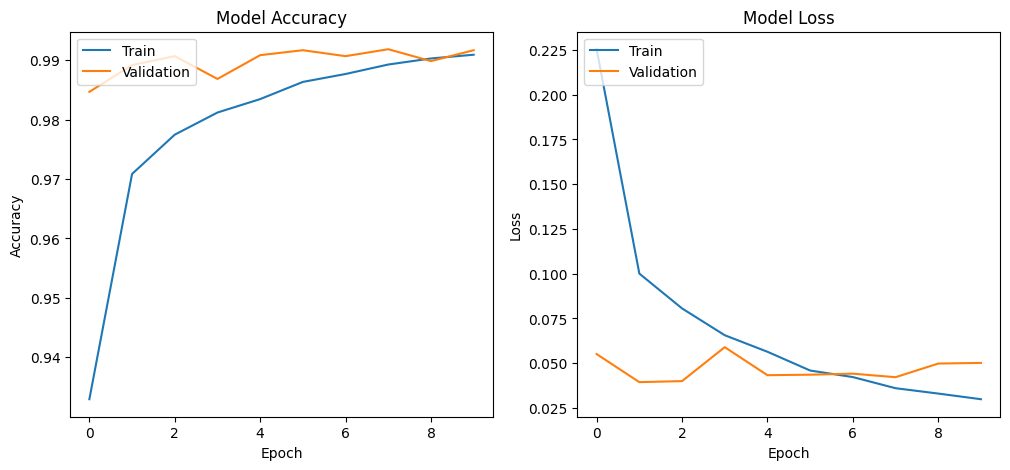

In [14]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

### **Step 7: Make Predictions**

Finally, let's use our trained model to make predictions on a few test images and visualize the results.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


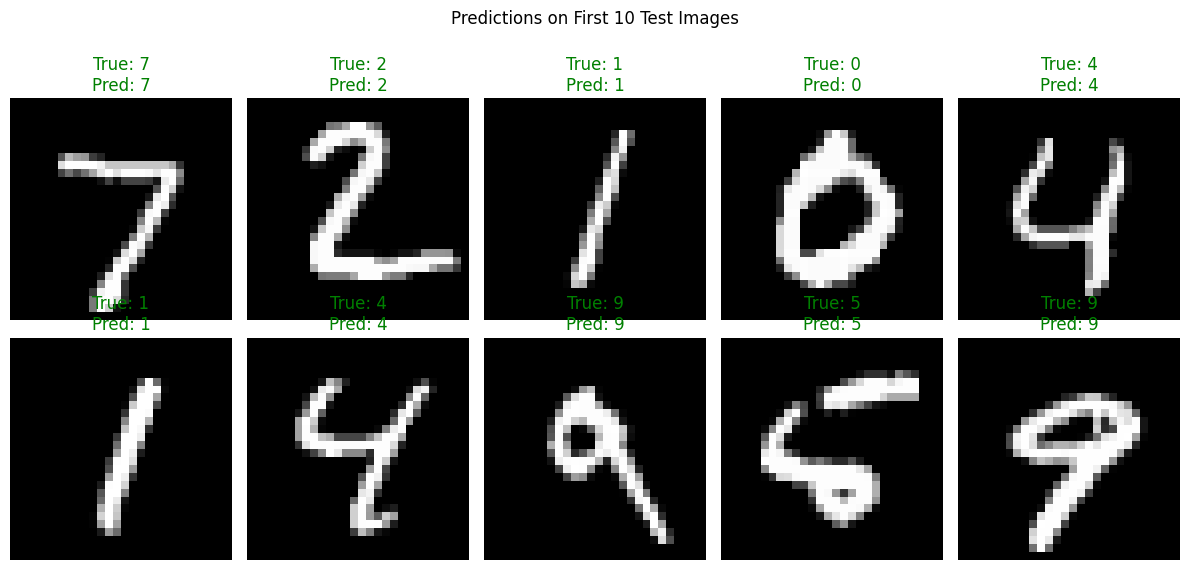

In [15]:
# Get predictions for the first 10 test images
predictions = model.predict(x_test[:10])
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels for the first 10 test images (before one-hot encoding)
true_classes = np.argmax(y_test[:10], axis=1)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshape back to (28, 28) for plotting
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_classes[i]}\nPred: {predicted_classes[i]}",
              color='green' if true_classes[i] == predicted_classes[i] else 'red')
    plt.axis('off')
plt.suptitle("Predictions on First 10 Test Images")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Next Steps for Your Internship Project:**

This provides a solid foundation. For your internship, you can explore further:

1.  **Experiment with Model Architecture**: Try adding more layers, different filter sizes, or different types of layers (e.g., `BatchNormalization`, more `Dropout`).
2.  **Hyperparameter Tuning**: Experiment with different optimizers, learning rates, batch sizes, and number of epochs.
3.  **Data Augmentation**: For smaller datasets, data augmentation (e.g., rotating, shifting images) can improve generalization.
4.  **Error Analysis**: Analyze where the model makes mistakes to understand its limitations.
5.  **Deployment**: Explore how to save your model and potentially deploy it (e.g., using TensorFlow Lite for mobile, or TensorFlow Serving for web).